# Cape Cauldron shear lines against the GLED eddy atlas

GLED v1.0 (Liu & Abernathey 2023,
[doi:10.5194/essd-15-1765-2023](https://doi.org/10.5194/essd-15-1765-2023),
data [doi:10.5281/zenodo.7349753](https://doi.org/10.5281/zenodo.7349753))
lists coherent Lagrangian eddies found from the Lagrangian averaged vorticity
deviation (Haller et al. 2016, J. Fluid Mech. 795,
[doi:10.1017/jfm.2016.151](https://doi.org/10.1017/jfm.2016.151)) on
trajectories advected with altimetry geostrophic currents. Its windows are
30 days long and start on the first of each month, and on 1 June 2018 it
places 23 eddies in the box 2E to 22E, 44S to 28S.

This notebook runs the closed-shear-line search of `cape_cauldron_vortices`
on the same kind of field, the DUACS geostrophic currents, over the same
window, and compares what the two methods find. GLED advects with the
1/4 degree DUACS product, so the search runs on the 1/8 degree product and on
its 1/4 degree block mean. The construction is the
$\eta_\lambda$ family of Haller & Beron-Vera (2013, Eq. 14,
[doi:10.1017/jfm.2013.391](https://doi.org/10.1017/jfm.2013.391)), whose
closed orbits are uniformly stretching material loops. The machinery below is
copied from that notebook rather than imported, so this one reads top to
bottom on its own.

The comparison runs twice. One sweep takes its candidate centres from the
Cauchy-Green field itself, so it tests the whole detection chain. The other
takes the GLED centres, so it tests only whether a closed shear line exists
where GLED puts an eddy.

In [1]:
# Importing Parcels pulls in the holoviews/bokeh bootstrap and prints an
# alpha-version notice, neither of which belongs on the rendered page.
import json

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr
from matplotlib.path import Path as MplPath
from parcels import FieldSet, Particle, ParticleSet, StatusCode
from parcels.convert import copernicusmarine_to_sgrid
from parcels.kernels import AdvectionRK4
from scipy.interpolate import RegularGridInterpolator

from lcs_parcels import NeighborSeedGrid
from lcs_parcels.grids import _M_PER_DEG, _separation_m
from lcs_parcels.tensorlines import _step_lonlat_by_meters

/var/folders/w1/m9mm9h9167z_gcfzfffr0rgsh6j6kj/T/ipykernel_7137/1503136219.py:10: UserWarning: This is an alpha version of Parcels v4. The API is not stable and may change without deprecation warnings.
  from parcels import FieldSet, Particle, ParticleSet, StatusCode


## Currents

Daily altimetry geostrophic velocity at 1/8 degree, the local file that
`get_data` writes.

In [2]:
currents_eighth = xr.open_dataset("data/cape_cauldron_geostrophic_daily.nc").load()
currents_eighth

<xarray.Dataset> Size: 40MB
Dimensions:    (time: 34, latitude: 256, longitude: 288)
Coordinates:
  * time       (time) datetime64[ns] 272B 2018-05-31 2018-06-01 ... 2018-07-03
  * latitude   (latitude) float32 1kB -51.94 -51.81 -51.69 ... -20.19 -20.06
  * longitude  (longitude) float32 1kB -5.938 -5.812 -5.688 ... 29.81 29.94
Data variables:
    ugos       (time, latitude, longitude) float64 20MB 0.04 0.0458 ... nan nan
    vgos       (time, latitude, longitude) float64 20MB 0.0334 0.0395 ... nan
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2023-12-31T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2023-12-30T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...
    copernicusmarine_version:        2.4.1

The 1/4 degree field is the 2 by 2 block mean of the 1/8 degree one, whose
cell centres fall on those of the 1/4 degree product. The mean skips land, so
a block that is part land takes the mean of its ocean cells.

GLED also removes the divergence that the latitude dependence of the Coriolis
parameter gives a geostrophic velocity. Neither field here has that
correction.

In [3]:
currents_quarter = currents_eighth.coarsen(
    latitude=2, longitude=2, boundary="trim"
).mean()
currents_quarter

<xarray.Dataset> Size: 10MB
Dimensions:    (time: 34, latitude: 128, longitude: 144)
Coordinates:
  * time       (time) datetime64[ns] 272B 2018-05-31 2018-06-01 ... 2018-07-03
  * latitude   (latitude) float32 512B -51.88 -51.62 -51.38 ... -20.38 -20.12
  * longitude  (longitude) float32 576B -5.875 -5.625 -5.375 ... 29.62 29.88
Data variables:
    ugos       (time, latitude, longitude) float64 5MB 0.04702 0.05183 ... nan
    vgos       (time, latitude, longitude) float64 5MB 0.03322 0.04813 ... nan
Attributes: (12/43)
    Conventions:                     CF-1.6
    Metadata_Conventions:            Unidata Dataset Discovery v1.0
    cdm_data_type:                   Grid
    comment:                         Sea Surface Height measured by Altimetry...
    contact:                         servicedesk.cmems@mercator-ocean.eu
    creator_email:                   servicedesk.cmems@mercator-ocean.eu
    ...                              ...
    time_coverage_duration:          P1D
    time_coverage_end:               2023-12-31T12:00:00Z
    time_coverage_resolution:        P1D
    time_coverage_start:             2023-12-30T12:00:00Z
    title:                           DT merged all satellites Global Ocean Gr...
    copernicusmarine_version:        2.4.1

## Parcels v4 field sets

The product carries no depth coordinate, so the fields have no `Z` axis and
the particle sets below are released with no `z`.

In [4]:
fieldset_eighth = FieldSet.from_sgrid_conventions(
    copernicusmarine_to_sgrid(
        fields={"U": currents_eighth["ugos"], "V": currents_eighth["vgos"]}
    ),
    mesh="spherical",
)
fieldset_quarter = FieldSet.from_sgrid_conventions(
    copernicusmarine_to_sgrid(
        fields={"U": currents_quarter["ugos"], "V": currents_quarter["vgos"]}
    ),
    mesh="spherical",
)

## Seed grid and window

The GLED box at 1/25 degree for both fields, released on 2018-06-01 at 00:00
and read at 30 days. GLED's `eddy_info_30d` product integrates forward over
the same interval and gives each eddy's centre and radius at the release
time, which is the time the Cauchy-Green fields below refer to.

In [5]:
t0 = np.datetime64("2018-06-01")
T = np.timedelta64(30, "D")
resolution_deg = 1 / 25
seed_lon, seed_lat = (2.0, 22.0), (-44.0, -28.0)

lon_axis = np.arange(seed_lon[0], seed_lon[1] + 1e-9, resolution_deg)
lat_axis = np.arange(seed_lat[0], seed_lat[1] + 1e-9, resolution_deg)
seed = NeighborSeedGrid.from_axes(lon=lon_axis, lat=lat_axis)
seed

<NeighborSeedGrid 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00>

## Recovery kernel

Particles that leave the domain or hit land are turned into `NaN` in place
(Parcels would otherwise abort the run), so losses propagate as `NaN`
through every diagnostic below. The kernel sets `StatusCode.EndofLoop`
rather than `StatusCode.Delete`, because deleting shrinks the particle
array and breaks the alignment with the seed order.

In [6]:
def set_lost_to_nan(particles, fieldset):
    lost = particles.state >= StatusCode.Error
    particles.x = np.where(lost, np.nan, particles.x)
    particles.y = np.where(lost, np.nan, particles.y)
    particles.state = np.where(lost, StatusCode.EndofLoop, particles.state)

## Advect forward

In [7]:
lon, lat = seed.to_parcels_pset()

In [8]:
# 1/8 degree
pset_eighth = ParticleSet(fieldset_eighth, pclass=Particle, x=lon, y=lat, t=t0)
pset_eighth.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=T,
    verbose_progress=False,
)
forward_eighth = seed.pset_to_flowmap(
    lon=pset_eighth.x, lat=pset_eighth.y, t0=t0, t1=t0 + T
)
forward_eighth

<NeighborFlowMap 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00,
                 t0 2018-06-01T00:00:00, T +30.0 days>

In [9]:
# 1/4 degree
pset_quarter = ParticleSet(fieldset_quarter, pclass=Particle, x=lon, y=lat, t=t0)
pset_quarter.execute(
    [AdvectionRK4, set_lost_to_nan],
    dt=np.timedelta64(1, "h"),
    runtime=T,
    verbose_progress=False,
)
forward_quarter = seed.pset_to_flowmap(
    lon=pset_quarter.x, lat=pset_quarter.y, t0=t0, t1=t0 + T
)
forward_quarter

<NeighborFlowMap 501x401 grid, lon 2.00..22.00, lat -44.00..-28.00,
                 t0 2018-06-01T00:00:00, T +30.0 days>

Particles lost to land or to the domain edge, at 1/8 and at 1/4 degree.

In [10]:
(
    int(np.isnan(np.asarray(pset_eighth.x)).sum()),
    int(np.isnan(np.asarray(pset_quarter.x)).sum()),
)

(23401, 23319)

## Eigendecomposition and FTLE

In [11]:
eigen_eighth = forward_eighth.cg_eigen()
eigen_quarter = forward_quarter.cg_eigen()
eigen_eighth

<xarray.Dataset> Size: 13MB
Dimensions:   (i: 501, j: 401, eig: 2, comp: 2)
Coordinates:
  * i         (i) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499 500
  * j         (j) int64 3kB 0 1 2 3 4 5 6 7 ... 393 394 395 396 397 398 399 400
    lon_grid  (i, j) float64 2MB 2.0 2.0 2.0 2.0 2.0 ... 22.0 22.0 22.0 22.0
    lat_grid  (i, j) float64 2MB -44.0 -43.96 -43.92 ... -28.08 -28.04 -28.0
  * eig       (eig) int64 16B 0 1
  * comp      (comp) <U1 8B 'x' 'y'
    t0        datetime64[s] 8B 2018-06-01
    T         timedelta64[s] 8B 30 days
Data variables:
    lambda    (i, j, eig) float64 3MB nan nan nan nan nan ... nan nan nan nan
    xi        (i, j, comp, eig) float64 6MB nan nan nan nan ... nan nan nan nan

In [12]:
ftle_eighth = forward_eighth.ftle()
ftle_quarter = forward_quarter.ftle()
ftle_eighth

<xarray.DataArray 'ftle' (i: 501, j: 401)> Size: 2MB
array([[           nan,            nan,            nan, ...,
                   nan,            nan,            nan],
       [           nan, 4.89067755e-07, 5.06663608e-07, ...,
        5.66777487e-07, 7.03259632e-07,            nan],
       [           nan, 7.85390829e-07, 6.78463251e-07, ...,
        5.43607530e-07, 7.10313007e-07,            nan],
       ...,
       [           nan, 1.34305269e-06, 1.39930656e-06, ...,
                   nan,            nan,            nan],
       [           nan, 1.20308246e-06, 1.45268016e-06, ...,
                   nan,            nan,            nan],
       [           nan,            nan,            nan, ...,
                   nan,            nan,            nan]], shape=(501, 401))
Coordinates:
  * i         (i) int64 4kB 0 1 2 3 4 5 6 7 ... 493 494 495 496 497 498 499 500
  * j         (j) int64 3kB 0 1 2 3 4 5 6 7 ... 393 394 395 396 397 398 399 400
    lon_grid  (i, j) float64 2MB 2.0 2.0 2.0 2.0 2.0 ... 22.0 22.0 22.0 22.0
    lat_grid  (i, j) float64 2MB -44.0 -43.96 -43.92 ... -28.08 -28.04 -28.0
    t0        datetime64[s] 8B 2018-06-01
    T         timedelta64[s] 8B 30 days
Attributes:
    long_name:  finite-time Lyapunov exponent
    units:      1/s

## The $\eta_\lambda$ tangent field

`shrink_lines` traces $\xi_1$ and takes no caller-supplied tangent field, so
the $\eta_\lambda$ field is built here. It follows the same scheme as the
library tracer, interpolating $C$ itself rather than the eigenvectors and
re-diagonalising at every evaluation.

$\xi_1$ and $\xi_2$ each carry a sign that `eigh` picks arbitrarily, and
flipping $\xi_2$ alone turns $\eta^+$ into $\eta^-$. The two signs are tied
together below so the two branches stay apart.

In [13]:
lon_grid_axis = forward_eighth.lon_grid.isel(j=0).values
lat_grid_axis = forward_eighth.lat_grid.isel(i=0).values
tensor_interp_eighth = RegularGridInterpolator(
    (lon_grid_axis, lat_grid_axis),
    forward_eighth.cauchy_green().transpose("i", "j", "row", "col").values,
    bounds_error=False,
    fill_value=np.nan,
)
tensor_interp_quarter = RegularGridInterpolator(
    (lon_grid_axis, lat_grid_axis),
    forward_quarter.cauchy_green().transpose("i", "j", "row", "col").values,
    bounds_error=False,
    fill_value=np.nan,
)


def eta_lambda_tangent(lon, lat, heading, *, lam, sign, tensor_interp):
    """Unit eta_lambda^{sign} (Haller & Beron-Vera 2013, Eq. 14, https://doi.org/10.1017/jfm.2013.391) at each point.

    NaN wherever off-grid, in a NaN cell, or lam**2 does not sit strictly
    inside (lambda_1, lambda_2), the well-definedness condition for eta_lambda.
    """
    C = tensor_interp(np.column_stack([lon, lat]))
    terminated = ~np.isfinite(C).all(axis=(1, 2))
    eigenvalues, eigenvectors = np.linalg.eigh(
        np.where(terminated[:, None, None], np.eye(2), C)
    )
    lam1, lam2 = np.maximum(eigenvalues[:, 0], 0.0), eigenvalues[:, 1]
    well_defined = (lam1 < lam**2) & (lam**2 < lam2)
    terminated = terminated | ~well_defined
    denom = np.maximum(lam2 - lam1, 1e-30)
    a = np.sqrt(np.clip((lam2 - lam**2) / denom, 0.0, 1.0))
    b = np.sqrt(np.clip((lam**2 - lam1) / denom, 0.0, 1.0))
    xi1 = eigenvectors[:, :, 0]
    # Taking xi_2 as xi_1 turned 90 degrees counter-clockwise ties the two
    # eigenvector signs together, so eta^+ and eta^- stay distinct.
    xi2 = np.column_stack([-xi1[:, 1], xi1[:, 0]])
    eta = a[:, None] * xi1 + sign * b[:, None] * xi2
    # Negating xi_1 negates xi_2 with it, so eta is fixed up to one overall
    # sign, and orienting it to the running heading stays inside one branch.
    eta[np.sum(eta * heading, axis=1) < 0] *= -1
    eta[terminated] = np.nan
    return eta

## RK2 tracer

Marches $\eta_\lambda$ one direction from a set of launch points with the
midpoint (RK2) scheme `shrink_lines` uses. The spherical step
`_step_lonlat_by_meters` is imported from `lcs_parcels.tensorlines`, where it
is private, since the package exposes no public tangent-field stepper.

In [14]:
def trace_eta_lines(*, lon_0, lat_0, lam, sign, step_m, n_steps, tensor_interp):
    lon = np.asarray(lon_0, dtype=float).ravel().copy()
    lat = np.asarray(lat_0, dtype=float).ravel().copy()
    heading = eta_lambda_tangent(
        lon,
        lat,
        np.ones((lon.size, 2)),
        lam=lam,
        sign=sign,
        tensor_interp=tensor_interp,
    )
    dead = ~np.isfinite(heading).all(axis=1)
    lon[dead], lat[dead] = np.nan, np.nan
    track_lon, track_lat = [lon.copy()], [lat.copy()]
    for _ in range(n_steps):
        direction = eta_lambda_tangent(
            lon, lat, heading, lam=lam, sign=sign, tensor_interp=tensor_interp
        )
        mid_lon, mid_lat = _step_lonlat_by_meters(
            lon, lat, 0.5 * direction, step_m=step_m
        )
        mid_direction = eta_lambda_tangent(
            mid_lon, mid_lat, direction, lam=lam, sign=sign, tensor_interp=tensor_interp
        )
        lon, lat = _step_lonlat_by_meters(lon, lat, mid_direction, step_m=step_m)
        heading = mid_direction
        track_lon.append(lon.copy())
        track_lat.append(lat.copy())
    return np.array(track_lon), np.array(track_lat)  # (n_steps + 1, n)

## Candidate vortex centres

Candidate centres are windowed minima of $\lambda_2/\lambda_1$, the points
where the eigendirections come closest to being undefined, with a guard
keeping a centre 50 km from the domain edge and from any NaN (land) cell.

The window is 100 km here rather than the 200 km of `cape_cauldron_vortices`.
The GLED eddies of this window sit 100 to 150 km apart, so a 200 km window
would drop one of a neighbouring pair.

In [15]:
def find_centres(field, *, window_m, edge_m):
    lon_grid, lat_grid = field["lon_grid"], field["lat_grid"]
    dx, _ = _separation_m(
        lon_a=lon_grid.shift(i=1),
        lat_a=lat_grid.shift(i=1),
        lon_b=lon_grid,
        lat_b=lat_grid,
    )
    _, dy = _separation_m(
        lon_a=lon_grid.shift(j=1),
        lat_a=lat_grid.shift(j=1),
        lon_b=lon_grid,
        lat_b=lat_grid,
    )
    spacing_i, spacing_j = float(np.abs(dx).median()), float(np.abs(dy).median())
    cells_i = max(
        1, round(window_m / spacing_i) - (round(window_m / spacing_i) % 2 == 0)
    )
    cells_j = max(
        1, round(window_m / spacing_j) - (round(window_m / spacing_j) % 2 == 0)
    )
    local_min = field.rolling(i=cells_i, j=cells_j, center=True, min_periods=1).min()
    is_centre = field <= local_min

    edge_cells_i = int(np.ceil(edge_m / spacing_i))
    edge_cells_j = int(np.ceil(edge_m / spacing_j))
    ni, nj = field.sizes["i"], field.sizes["j"]
    valid_window = (
        field.notnull()
        .astype(float)
        .rolling(
            i=2 * edge_cells_i + 1, j=2 * edge_cells_j + 1, center=True, min_periods=1
        )
        .min()
    )
    i_idx, j_idx = (
        xr.DataArray(np.arange(ni), dims="i"),
        xr.DataArray(np.arange(nj), dims="j"),
    )
    near_edge = (
        (i_idx < edge_cells_i)
        | (i_idx >= ni - edge_cells_i)
        | (j_idx < edge_cells_j)
        | (j_idx >= nj - edge_cells_j)
    )
    keep = is_centre & field.notnull() & (valid_window > 0.5) & ~near_edge
    picked = (
        xr.Dataset({"lon": lon_grid, "lat": lat_grid, "value": field})
        .stack(pt=("i", "j"))
        .where(keep.stack(pt=("i", "j")), drop=True)
    )
    return picked["lon"].values, picked["lat"].values, picked["value"].values

In [16]:
# 1/8 degree
anisotropy_eighth = (
    (eigen_eighth["lambda"].isel(eig=1) / eigen_eighth["lambda"].isel(eig=0))
    .rename("anisotropy")
    .assign_attrs(long_name="Cauchy-Green eigenvalue ratio", units="1")
)
centre_lon_eighth, centre_lat_eighth, _ = find_centres(
    anisotropy_eighth, window_m=100_000.0, edge_m=50_000.0
)

In [17]:
# 1/4 degree
anisotropy_quarter = (
    (eigen_quarter["lambda"].isel(eig=1) / eigen_quarter["lambda"].isel(eig=0))
    .rename("anisotropy")
    .assign_attrs(long_name="Cauchy-Green eigenvalue ratio", units="1")
)
centre_lon_quarter, centre_lat_quarter, _ = find_centres(
    anisotropy_quarter, window_m=100_000.0, edge_m=50_000.0
)

Candidate centres at 1/8 and at 1/4 degree.

In [18]:
len(centre_lon_eighth), len(centre_lon_quarter)

(226, 250)

## Poincaré sections and the return map

A section runs due east from each candidate centre and a second runs due west,
so an orbit whose eastern arc leaves the admissible region is still found on
the western one. `first_return` walks each traced line and finds the first
crossing of a section after the line has moved away from it, linearly
interpolating the crossing longitude. Both `s` and `P(s)` are arc length from
the centre along the section, and a zero of $P(s) - s$ is a closed orbit.

The scan runs $\lambda$ from 0.80 to 1.60, which brackets the area-preserving
value where the geostrophic flow is close to non-divergent.

In [19]:
SECTION_LENGTH_M = 150_000.0
N_LAUNCH = 30
STEP_M = 2_000.0
RING_DIAMETER_M = 200_000.0  # the GLED eddies here reach a 100 km radius
BUDGET_M = 2 * np.pi * (RING_DIAMETER_M / 2) * 2  # two circumferences
N_STEPS = round(BUDGET_M / STEP_M)
LAMBDAS = np.arange(0.80, 1.60 + 1e-9, 0.05)
SIGNS = [+1, -1]
DIRECTIONS = [+1, -1]  # east, west
CLOSE_TOL_M = 2_000.0


def section_points(*, centre_lon, centre_lat, length_m, n, direction):
    """Launch points along the section running east (+1) or west (-1)."""
    s = np.linspace(0.0, length_m, n)
    lon = centre_lon + direction * s / (_M_PER_DEG * np.cos(np.deg2rad(centre_lat)))
    lat = np.full(n, centre_lat)
    return s, lon, lat


def section_arc_length(lon, *, centre_lon, centre_lat, direction):
    """Arc length from the centre along the section, positive along it."""
    return direction * (lon - centre_lon) * _M_PER_DEG * np.cos(np.deg2rad(centre_lat))


def first_return(
    *, track_lon, track_lat, section_lat, section_lon_min, section_lon_max
):
    """First crossing of the section segment after the line has moved off it.

    Returns the crossing longitude, NaN where the line never comes back, and
    the number of track points up to and including the crossing step.

    A line encircling the centre also crosses the section latitude on the far
    side, outside the segment. That is not a return, and the scan runs on.
    """
    n_steps_p1, n_lines = track_lon.shape
    north_rel = track_lat - section_lat
    result_lon = np.full(n_lines, np.nan)
    cut = np.full(n_lines, n_steps_p1, dtype=int)
    for k in range(n_lines):
        lon_k, rel_k = track_lon[:, k], north_rel[:, k]
        started_away = False
        for i in range(1, n_steps_p1):
            if not (np.isfinite(rel_k[i]) and np.isfinite(lon_k[i])):
                break
            if not started_away:
                started_away = abs(rel_k[i]) > 1e-9
                continue
            if rel_k[i - 1] == 0 or (np.sign(rel_k[i - 1]) != np.sign(rel_k[i])):
                t = rel_k[i - 1] / (rel_k[i - 1] - rel_k[i])
                lon_cross = lon_k[i - 1] + t * (lon_k[i] - lon_k[i - 1])
                if section_lon_min - 1e-6 <= lon_cross <= section_lon_max + 1e-6:
                    result_lon[k], cut[k] = lon_cross, i + 1
                    break
    return result_lon, cut

## The sweep

For every candidate centre, every $\lambda$, each sign of $\eta_\lambda$ and
each section, the sweep finds the sign changes of $P(s) - s$ across
neighbouring launch points, refines each by linear interpolation, re-traces
from the refined $s$, and accepts it as a closed orbit when the residual return
displacement is under `CLOSE_TOL_M`.

A residual-only check accepts a line that merely grazes back across the
section without enclosing the centre, so every candidate also has to enclose
the centre and have a circumference within a factor of 2 of $2\pi r$ for its
mean radius $r$.

The sweep also records, for each combination, how far around the centre its
best launch point gets before the line ends. A closed orbit needs a full
revolution, so that number bounds what the search can find.

In [20]:
def revolutions(*, track_lon, track_lat, centre_lon, centre_lat):
    """Turns each traced line makes about the centre before it terminates."""
    dx, dy = _separation_m(
        lon_a=centre_lon, lat_a=centre_lat, lon_b=track_lon, lat_b=track_lat
    )
    angle = np.unwrap(np.arctan2(dy, dx), axis=0)
    turns = np.full(track_lon.shape[1], np.nan)
    for k in range(track_lon.shape[1]):
        finite = np.isfinite(angle[:, k])
        if finite.sum() > 1:
            ends = angle[finite, k]
            turns[k] = (ends[-1] - ends[0]) / (2 * np.pi)
    return turns

In [21]:
def sweep_centres(*, centre_lon, centre_lat, lambdas, signs, tensor_interp):
    """Closed-orbit search over every candidate centre, lambda, sign and section."""
    closed_orbits = []
    winding = []
    n_never_return = 0

    for ci, (cl, ca) in enumerate(zip(centre_lon, centre_lat, strict=True)):
        for direction in DIRECTIONS:
            s_vals, launch_lon, launch_lat = section_points(
                centre_lon=cl,
                centre_lat=ca,
                length_m=SECTION_LENGTH_M,
                n=N_LAUNCH,
                direction=direction,
            )
            lon_min, lon_max = launch_lon.min(), launch_lon.max()
            for lam in lambdas:
                for sign in signs:
                    track_lon, track_lat = trace_eta_lines(
                        lon_0=launch_lon,
                        lat_0=launch_lat,
                        lam=lam,
                        sign=sign,
                        step_m=STEP_M,
                        n_steps=N_STEPS,
                        tensor_interp=tensor_interp,
                    )
                    turns = revolutions(
                        track_lon=track_lon,
                        track_lat=track_lat,
                        centre_lon=cl,
                        centre_lat=ca,
                    )
                    if np.isfinite(turns).any():
                        k_best = int(np.nanargmax(np.abs(turns)))
                        winding.append(
                            {
                                "centre_idx": ci,
                                "centre_lon": cl,
                                "centre_lat": ca,
                                "direction": direction,
                                "lam": lam,
                                "sign": sign,
                                "s": s_vals[k_best],
                                "turns": turns[k_best],
                                "steps": int(np.isfinite(track_lon[:, k_best]).sum()),
                            }
                        )
                    ret_lon, _ = first_return(
                        track_lon=track_lon,
                        track_lat=track_lat,
                        section_lat=ca,
                        section_lon_min=lon_min,
                        section_lon_max=lon_max,
                    )
                    ret_s = section_arc_length(
                        ret_lon, centre_lon=cl, centre_lat=ca, direction=direction
                    )
                    if not np.isfinite(ret_s).any():
                        n_never_return += 1
                        continue
                    P_minus_s = ret_s - s_vals
                    finite = np.isfinite(P_minus_s)
                    for i in range(N_LAUNCH - 1):
                        if not (finite[i] and finite[i + 1]):
                            continue
                        a, b = P_minus_s[i], P_minus_s[i + 1]
                        if not (a == 0 or np.sign(a) != np.sign(b)):
                            continue
                        t = a / (a - b)
                        s_fix = s_vals[i] + t * (s_vals[i + 1] - s_vals[i])
                        dlon = direction * s_fix / (_M_PER_DEG * np.cos(np.deg2rad(ca)))
                        poly_lon, poly_lat = trace_eta_lines(
                            lon_0=np.array([cl + dlon]),
                            lat_0=np.array([ca]),
                            lam=lam,
                            sign=sign,
                            step_m=STEP_M,
                            n_steps=N_STEPS,
                            tensor_interp=tensor_interp,
                        )
                        ret_lon2, cut_arr = first_return(
                            track_lon=poly_lon,
                            track_lat=poly_lat,
                            section_lat=ca,
                            section_lon_min=lon_min,
                            section_lon_max=lon_max,
                        )
                        if not np.isfinite(ret_lon2[0]):
                            continue
                        ret_s2 = section_arc_length(
                            ret_lon2[0],
                            centre_lon=cl,
                            centre_lat=ca,
                            direction=direction,
                        )
                        residual_m = abs(ret_s2 - s_fix)
                        if residual_m >= CLOSE_TOL_M:
                            continue
                        cut = int(cut_arr[0])
                        dx, dy = _separation_m(
                            lon_a=cl,
                            lat_a=ca,
                            lon_b=poly_lon[:cut, 0],
                            lat_b=poly_lat[:cut, 0],
                        )
                        radius_m = np.hypot(dx, dy)
                        mean_radius_m = float(np.nanmean(radius_m))
                        encloses = MplPath(np.column_stack([dx, dy])).contains_point(
                            (0.0, 0.0)
                        )
                        length_m = np.sum(
                            np.hypot(
                                np.diff(np.append(dx, dx[0])),
                                np.diff(np.append(dy, dy[0])),
                            )
                        )
                        circumference_ratio = (
                            length_m / (2 * np.pi * mean_radius_m)
                            if mean_radius_m > 0
                            else np.nan
                        )
                        closed_orbits.append(
                            {
                                "centre_idx": ci,
                                "centre_lon": cl,
                                "centre_lat": ca,
                                "direction": direction,
                                "lam": lam,
                                "sign": sign,
                                "s": s_fix,
                                "residual_m": residual_m,
                                "lon": poly_lon[:cut, 0],
                                "lat": poly_lat[:cut, 0],
                                "mean_radius_m": mean_radius_m,
                                "encloses_centre": bool(encloses),
                                "circumference_ratio": float(circumference_ratio),
                            }
                        )
    return closed_orbits, winding, n_never_return

In [22]:
def keep_closed(candidates):
    """The candidates that enclose their centre and have a plausible shape."""
    return [
        o
        for o in candidates
        if o["encloses_centre"] and 0.5 < o["circumference_ratio"] < 2.0
    ]

In [23]:
def outermost_per_centre(orbits):
    """The largest-mean-radius closed orbit at each centre."""
    outermost = {}
    for o in orbits:
        ci = o["centre_idx"]
        if ci not in outermost or o["mean_radius_m"] > outermost[ci]["mean_radius_m"]:
            outermost[ci] = o
    return outermost

In [24]:
def orbit_table(orbits):
    """One row per orbit, sorted by mean radius, with the radius in km."""
    return pd.DataFrame(
        [
            {
                "centre_lon": o["centre_lon"],
                "centre_lat": o["centre_lat"],
                "lam": o["lam"],
                "sign": o["sign"],
                "section": o["direction"],
                "mean_radius_km": o["mean_radius_m"] / 1000,
                "circumference_ratio": o["circumference_ratio"],
                "residual_m": o["residual_m"],
            }
            for o in sorted(orbits, key=lambda o: o["mean_radius_m"])
        ]
    ).round(
        {
            "centre_lon": 2,
            "centre_lat": 2,
            "lam": 2,
            "mean_radius_km": 1,
            "circumference_ratio": 3,
            "residual_m": 1,
        }
    )

## The GLED records

`eddy_info_30d.json` and `eddy_info_90d.json` each map an eddy id to its
`date_start`, `radius` in km, polarity `cyc`, and centre position sampled
every 10 days. Index 0 of `center_lon`/`center_lat` is the position at the
start date, which is what selects an eddy into the box here.

In [25]:
def load_gled(path, *, date_start, lon_bounds, lat_bounds):
    """GLED eddies starting on `date_start` whose start position is in the box."""
    with open(path) as f:
        raw = json.load(f)
    ids, eddy_lon, eddy_lat, radius_km, polarity, lifetime = [], [], [], [], [], []
    for key, start in raw["date_start"].items():
        if start != date_start:
            continue
        # GLED stores 0-360 longitudes, and this box is east of Greenwich.
        lon_0 = ((raw["center_lon"][key][0] + 180.0) % 360.0) - 180.0
        lat_0 = raw["center_lat"][key][0]
        if not (lon_bounds[0] <= lon_0 <= lon_bounds[1]):
            continue
        if not (lat_bounds[0] <= lat_0 <= lat_bounds[1]):
            continue
        ids.append(raw["id"][key])
        eddy_lon.append(lon_0)
        eddy_lat.append(lat_0)
        radius_km.append(raw["radius"][key])
        polarity.append(raw["cyc"][key])
        lifetime.append(raw["duration"][key])
    return xr.Dataset(
        {
            "lon": (
                "eddy",
                np.array(eddy_lon, dtype=float),
                {"long_name": "GLED eddy centre longitude", "units": "degrees_east"},
            ),
            "lat": (
                "eddy",
                np.array(eddy_lat, dtype=float),
                {"long_name": "GLED eddy centre latitude", "units": "degrees_north"},
            ),
            "radius_m": (
                "eddy",
                np.array(radius_km, dtype=float) * 1000.0,
                {"long_name": "GLED eddy radius", "units": "m"},
            ),
            "polarity": (
                "eddy",
                np.array(polarity, dtype=int),
                {
                    "long_name": "GLED eddy polarity, 1 anticyclonic and -1 cyclonic",
                    "units": "1",
                },
            ),
            "lifetime_days": (
                "eddy",
                np.array(lifetime, dtype=float),
                {"long_name": "GLED eddy tracking duration", "units": "days"},
            ),
        },
        coords={"eddy": ("eddy", ids, {"long_name": "GLED eddy identifier"})},
    )

In [26]:
gled_30 = load_gled(
    "data/gled/eddyinfo/eddy_info_30d.json",
    date_start="2018-06-01",
    lon_bounds=seed_lon,
    lat_bounds=seed_lat,
)
gled_90 = load_gled(
    "data/gled/eddyinfo/eddy_info_90d.json",
    date_start="2018-06-01",
    lon_bounds=seed_lon,
    lat_bounds=seed_lat,
)
gled_30.sizes["eddy"], gled_90.sizes["eddy"]

(23, 3)

In [27]:
gled_30

<xarray.Dataset> Size: 3kB
Dimensions:        (eddy: 23)
Coordinates:
  * eddy           (eddy) <U24 2kB '2018-06-01_030day_000047' ... '2018-06-01...
Data variables:
    lon            (eddy) float64 184B 15.73 13.67 8.516 ... 7.297 2.891 2.047
    lat            (eddy) float64 184B -39.58 -35.3 -40.48 ... -30.42 -38.52
    radius_m       (eddy) float64 184B 7.25e+04 8.009e+04 ... 3.098e+04
    polarity       (eddy) int64 184B 1 -1 1 1 1 1 -1 -1 -1 ... 1 1 1 1 -1 1 -1 1
    lifetime_days  (eddy) float64 184B 30.0 30.0 30.0 30.0 ... 30.0 30.0 30.0

## Sweep A, centres from the Cauchy-Green field

The whole detection chain, candidate centres included. The four numbers are
the candidates that pass the return-map residual, those that also enclose
their centre with a plausible shape, the centres with a closed orbit, and the
centre, section, $\lambda$ and sign combinations that never return.

In [28]:
# 1/8 degree
candidates_a_eighth, _, n_never_return_a_eighth = sweep_centres(
    centre_lon=centre_lon_eighth,
    centre_lat=centre_lat_eighth,
    lambdas=LAMBDAS,
    signs=SIGNS,
    tensor_interp=tensor_interp_eighth,
)
closed_a_eighth = keep_closed(candidates_a_eighth)
outermost_a_eighth = outermost_per_centre(closed_a_eighth)
(
    len(candidates_a_eighth),
    len(closed_a_eighth),
    len(outermost_a_eighth),
    n_never_return_a_eighth,
)

(64, 27, 7, 7859)

In [29]:
orbit_table(closed_a_eighth)

,centre_lon,centre_lat,lam,sign,section,mean_radius_km,circumference_ratio,residual_m
0,8.48,-40.48,0.90,1,-1,5.6,1.007,786.7
1,14.56,-31.56,0.95,-1,-1,6.7,0.959,29.0
2,8.48,-40.48,0.90,1,1,12.5,0.997,39.8
3,8.48,-40.48,0.90,1,-1,12.7,1.024,1.4
4,5.36,-33.56,0.95,-1,1,12.9,1.018,27.0
5,5.36,-33.56,0.95,-1,-1,13.1,1.038,52.2
6,6.64,-39.72,1.00,-1,1,17.6,0.956,302.1
7,5.16,-30.96,1.00,1,1,18.3,1.018,86.8
8,5.16,-30.96,1.00,1,1,19.5,1.021,4.3
9,5.16,-30.96,1.00,1,-1,20.5,1.041,11.4


In [30]:
# 1/4 degree
candidates_a_quarter, _, n_never_return_a_quarter = sweep_centres(
    centre_lon=centre_lon_quarter,
    centre_lat=centre_lat_quarter,
    lambdas=LAMBDAS,
    signs=SIGNS,
    tensor_interp=tensor_interp_quarter,
)
closed_a_quarter = keep_closed(candidates_a_quarter)
outermost_a_quarter = outermost_per_centre(closed_a_quarter)
(
    len(candidates_a_quarter),
    len(closed_a_quarter),
    len(outermost_a_quarter),
    n_never_return_a_quarter,
)

(90, 34, 7, 8268)

In [31]:
orbit_table(closed_a_quarter)

,centre_lon,centre_lat,lam,sign,section,mean_radius_km,circumference_ratio,residual_m
0,13.56,-35.32,0.90,-1,1,9.6,0.945,75.8
1,14.56,-31.56,1.05,-1,-1,10.9,0.960,85.5
2,8.44,-40.48,0.80,1,-1,11.9,0.997,54.7
3,5.16,-30.96,1.00,1,1,13.3,1.015,443.0
4,5.16,-30.96,1.00,1,-1,13.8,1.054,757.8
5,8.44,-40.48,0.85,1,-1,14.1,0.993,69.8
6,14.56,-31.56,1.00,-1,-1,14.5,0.981,74.6
7,5.36,-33.56,1.00,-1,-1,14.6,1.013,136.1
8,8.44,-40.48,0.90,1,-1,16.3,0.998,0.3
9,14.56,-31.56,1.00,-1,1,16.3,0.962,718.0


## Sweep B, centres from GLED

The same search launched from the GLED 30-day eddy centres. It separates
centre selection from the existence of a closed shear line, since a centre
GLED found cannot be missed here.

In [32]:
# 1/8 degree
candidates_b_eighth, _, n_never_return_b_eighth = sweep_centres(
    centre_lon=gled_30["lon"].values,
    centre_lat=gled_30["lat"].values,
    lambdas=LAMBDAS,
    signs=SIGNS,
    tensor_interp=tensor_interp_eighth,
)
closed_b_eighth = keep_closed(candidates_b_eighth)
outermost_b_eighth = outermost_per_centre(closed_b_eighth)
(
    len(candidates_b_eighth),
    len(closed_b_eighth),
    len(outermost_b_eighth),
    n_never_return_b_eighth,
)

(26, 19, 7, 700)

In [33]:
orbit_table(closed_b_eighth)

,centre_lon,centre_lat,lam,sign,section,mean_radius_km,circumference_ratio,residual_m
0,14.52,-31.61,0.95,-1,-1,6.8,1.129,34.1
1,5.30,-30.95,1.00,1,-1,12.4,0.771,1517.2
2,8.52,-40.48,0.90,1,1,13.6,0.998,119.0
3,8.52,-40.48,0.90,1,-1,14.0,0.975,111.5
4,10.33,-41.52,1.25,-1,1,14.7,0.941,423.9
5,10.33,-41.52,1.25,-1,-1,16.0,0.897,389.8
6,11.39,-32.86,1.00,-1,1,19.0,0.893,181.5
7,5.30,-30.95,1.00,1,-1,19.4,0.962,23.4
8,5.30,-30.95,1.00,1,-1,19.9,0.973,41.2
9,14.52,-31.61,0.90,-1,-1,32.4,1.016,88.7


In [34]:
# 1/4 degree
candidates_b_quarter, _, n_never_return_b_quarter = sweep_centres(
    centre_lon=gled_30["lon"].values,
    centre_lat=gled_30["lat"].values,
    lambdas=LAMBDAS,
    signs=SIGNS,
    tensor_interp=tensor_interp_quarter,
)
closed_b_quarter = keep_closed(candidates_b_quarter)
outermost_b_quarter = outermost_per_centre(closed_b_quarter)
(
    len(candidates_b_quarter),
    len(closed_b_quarter),
    len(outermost_b_quarter),
    n_never_return_b_quarter,
)

(33, 26, 7, 668)

In [35]:
orbit_table(closed_b_quarter)

,centre_lon,centre_lat,lam,sign,section,mean_radius_km,circumference_ratio,residual_m
0,13.67,-35.30,0.90,-1,1,9.6,0.898,99.1
1,13.67,-35.30,0.90,-1,-1,11.1,0.908,830.0
2,8.52,-40.48,0.80,1,-1,12.9,0.960,144.8
3,14.52,-31.61,1.00,-1,-1,13.4,1.026,17.6
4,8.52,-40.48,0.85,1,-1,14.9,0.943,27.0
5,14.52,-31.61,1.00,-1,1,15.5,1.045,770.0
6,8.52,-40.48,0.90,1,-1,17.2,0.977,140.7
7,14.52,-31.61,0.95,-1,-1,19.2,1.013,0.3
8,8.52,-40.48,0.95,1,-1,19.9,0.989,65.7
9,8.52,-40.48,0.95,1,1,21.8,0.985,1222.8


## Matching

Each GLED eddy is paired with the nearest outermost orbit of sweep A, and each
outermost orbit with the nearest GLED eddy. A pair counts as matched when the
orbit centre falls inside the GLED radius.

In [36]:
def nearest(*, lon_from, lat_from, lon_to, lat_to):
    """Index of and distance in metres to the nearest of the target points."""
    if len(lon_to) == 0:
        return None, np.nan
    dx, dy = _separation_m(
        lon_a=lon_from,
        lat_a=lat_from,
        lon_b=np.asarray(lon_to),
        lat_b=np.asarray(lat_to),
    )
    distance = np.hypot(dx, dy)
    k = int(np.argmin(distance))
    return k, float(distance[k])

In [37]:
def match_to_gled(outermost, *, gled):
    """One table per GLED eddy and one per orbit centre, distances and radii in km.

    `inside` marks a pair whose orbit centre falls inside the GLED radius.
    """
    orbit_lon = np.array([o["centre_lon"] for o in outermost.values()])
    orbit_lat = np.array([o["centre_lat"] for o in outermost.values()])
    orbit_radius_m = np.array([o["mean_radius_m"] for o in outermost.values()])

    per_eddy = []
    for e in range(gled.sizes["eddy"]):
        eddy = gled.isel(eddy=e)
        k, distance_m = nearest(
            lon_from=float(eddy["lon"]),
            lat_from=float(eddy["lat"]),
            lon_to=orbit_lon,
            lat_to=orbit_lat,
        )
        per_eddy.append(
            {
                "gled_lon": float(eddy["lon"]),
                "gled_lat": float(eddy["lat"]),
                "gled_radius_km": float(eddy["radius_m"]) / 1000,
                "distance_km": distance_m / 1000,
                "orbit_radius_km": np.nan if k is None else orbit_radius_m[k] / 1000,
                "inside": bool(distance_m <= float(eddy["radius_m"])),
            }
        )

    per_orbit = []
    for k in range(len(orbit_lon)):
        e, distance_m = nearest(
            lon_from=orbit_lon[k],
            lat_from=orbit_lat[k],
            lon_to=gled["lon"].values,
            lat_to=gled["lat"].values,
        )
        gled_radius_m = float(gled["radius_m"].isel(eddy=e))
        per_orbit.append(
            {
                "centre_lon": orbit_lon[k],
                "centre_lat": orbit_lat[k],
                "orbit_radius_km": orbit_radius_m[k] / 1000,
                "distance_km": distance_m / 1000,
                "gled_radius_km": gled_radius_m / 1000,
                "inside": bool(distance_m <= gled_radius_m),
            }
        )
    return pd.DataFrame(per_eddy), pd.DataFrame(per_orbit)

In [38]:
per_eddy_eighth, per_orbit_eighth = match_to_gled(outermost_a_eighth, gled=gled_30)
per_eddy_quarter, per_orbit_quarter = match_to_gled(outermost_a_quarter, gled=gled_30)

Each GLED 30-day eddy with the nearest sweep-A orbit, at 1/8 degree.

In [39]:
per_eddy_eighth.round(2)

,gled_lon,gled_lat,gled_radius_km,distance_km,orbit_radius_km,inside
0,15.73,-39.58,72.50,509.59,42.81,False
1,13.67,-35.30,80.09,7.01,42.81,True
2,8.52,-40.48,73.27,3.05,57.27,True
3,14.42,-41.05,65.07,504.38,57.27,False
4,13.27,-41.39,65.07,414.56,57.27,False
5,13.89,-42.11,64.55,486.98,57.27,False
6,11.39,-32.86,86.62,331.34,6.75,False
7,14.52,-31.61,58.92,6.91,6.75,True
8,20.80,-41.17,31.84,904.66,42.81,False
9,5.30,-30.95,100.40,13.07,59.29,True


The same at 1/4 degree.

In [40]:
per_eddy_quarter.round(2)

,gled_lon,gled_lat,gled_radius_km,distance_km,orbit_radius_km,inside
0,15.73,-39.58,72.50,21.38,21.19,True
1,13.67,-35.30,80.09,10.47,9.59,True
2,8.52,-40.48,73.27,6.41,52.21,True
3,14.42,-41.05,65.07,197.58,21.19,False
4,13.27,-41.39,65.07,285.55,21.19,False
5,13.89,-42.11,64.55,322.95,21.19,False
6,11.39,-32.86,86.62,29.34,29.15,True
7,14.52,-31.61,58.92,6.91,32.20,True
8,20.80,-41.17,31.84,485.28,21.19,False
9,5.30,-30.95,100.40,13.07,66.61,True


Each sweep-A outermost orbit with the nearest GLED eddy, at 1/8 degree.

In [41]:
per_orbit_eighth.round(2)

,centre_lon,centre_lat,orbit_radius_km,distance_km,gled_radius_km,inside
0,5.16,-30.96,59.29,13.07,100.40,True
1,5.36,-33.56,13.11,14.27,65.16,True
2,6.64,-39.72,27.63,180.76,73.27,False
3,7.44,-30.36,42.70,215.35,100.40,False
4,8.48,-40.48,57.27,3.05,73.27,True
5,13.60,-35.32,42.81,7.01,80.09,True
6,14.56,-31.56,6.75,6.91,58.92,True


The same at 1/4 degree.

In [42]:
per_orbit_quarter.round(2)

,centre_lon,centre_lat,orbit_radius_km,distance_km,gled_radius_km,inside
0,5.16,-30.96,66.61,13.07,100.40,True
1,5.36,-33.56,19.85,14.27,65.16,True
2,8.44,-40.48,52.21,6.41,73.27,True
3,11.44,-33.12,29.15,29.34,86.62,True
4,13.56,-35.32,9.59,10.47,80.09,True
5,14.56,-31.56,32.20,6.91,58.92,True
6,15.52,-39.48,21.19,21.38,72.50,True


## The two resolutions side by side

The radius ratio is the orbit mean radius over the GLED radius, over the
matched GLED eddies.

In [43]:
def summary(*, n_centres, closed_a, outermost_a, outermost_b, per_eddy, per_orbit):
    """The headline numbers of one resolution."""
    matched = per_eddy[per_eddy["inside"]]
    ratio = matched["orbit_radius_km"] / matched["gled_radius_km"]
    lam = [o["lam"] for o in closed_a]
    return {
        "candidate centres": n_centres,
        "closed orbits, A": len(closed_a),
        "centres with a closed orbit, A": len(outermost_a),
        "A centres inside a GLED eddy": int(per_orbit["inside"].sum()),
        "GLED eddies matched": int(per_eddy["inside"].sum()),
        "radius ratio, median": float(ratio.median()),
        "radius ratio, mean": float(ratio.mean()),
        "lambda of closed orbits, min": float(min(lam)),
        "lambda of closed orbits, max": float(max(lam)),
        "centres with a closed orbit, B": len(outermost_b),
    }

In [44]:
pd.DataFrame(
    {
        "1/8 degree": summary(
            n_centres=len(centre_lon_eighth),
            closed_a=closed_a_eighth,
            outermost_a=outermost_a_eighth,
            outermost_b=outermost_b_eighth,
            per_eddy=per_eddy_eighth,
            per_orbit=per_orbit_eighth,
        ),
        "1/4 degree": summary(
            n_centres=len(centre_lon_quarter),
            closed_a=closed_a_quarter,
            outermost_a=outermost_a_quarter,
            outermost_b=outermost_b_quarter,
            per_eddy=per_eddy_quarter,
            per_orbit=per_orbit_quarter,
        ),
    }
).round(3)

,1/8 degree,1/4 degree
candidate centres,226.000,250.000
"closed orbits, A",27.000,34.000
"centres with a closed orbit, A",7.000,7.000
A centres inside a GLED eddy,5.000,7.000
GLED eddies matched,5.000,7.000
"radius ratio, median",0.535,0.337
"radius ratio, mean",0.444,0.425
"lambda of closed orbits, min",0.900,0.800
"lambda of closed orbits, max",1.350,1.100
"centres with a closed orbit, B",7.000,7.000


## The FTLE fields

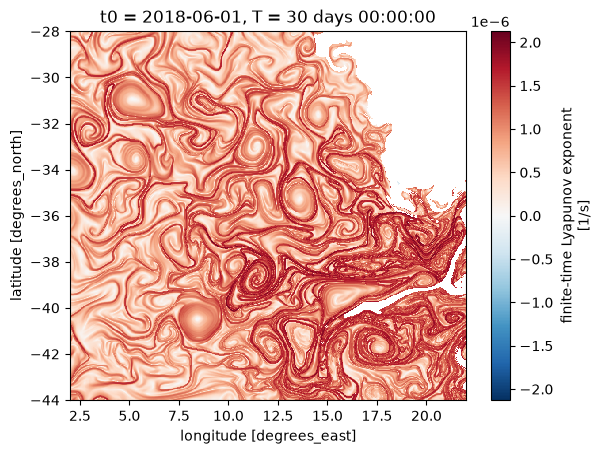

In [45]:
ftle_eighth.plot.pcolormesh(x="lon_grid", y="lat_grid")

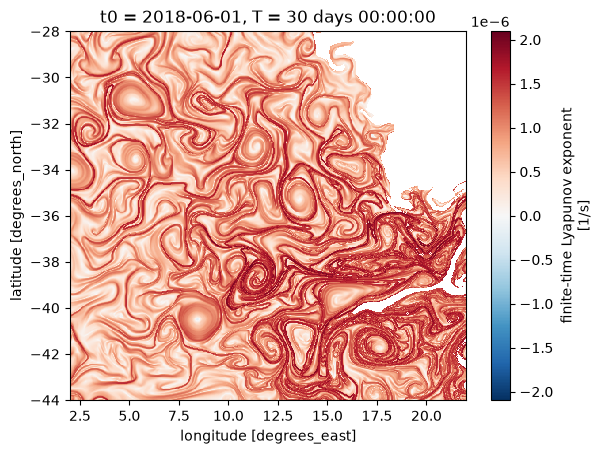

In [46]:
ftle_quarter.plot.pcolormesh(x="lon_grid", y="lat_grid")

## GLED and the closed shear lines

The GLED eddies as circles at their radius, blue for cyclonic and red for
anticyclonic, with a thick outline where the 90-day product carries the eddy
too. A 90-day eddy is coherent over three times the window here, so its
outline marks persistence and not a 30-day boundary. The outermost orbits of
sweep A are drawn solid and those of sweep B dashed.

In [47]:
def plot_against_gled(ftle, *, outermost_a, outermost_b):
    theta = np.linspace(0.0, 2 * np.pi, 200)
    _, ax = plt.subplots(figsize=(11, 8))
    ftle.plot.pcolormesh(x="lon_grid", y="lat_grid", ax=ax, cmap="Greys")
    for records, width in ((gled_30, 1.2), (gled_90, 3.0)):
        for e in range(records.sizes["eddy"]):
            eddy = records.isel(eddy=e)
            centre_lon_e, centre_lat_e = float(eddy["lon"]), float(eddy["lat"])
            radius_deg = float(eddy["radius_m"]) / _M_PER_DEG
            ax.plot(
                centre_lon_e
                + radius_deg * np.cos(theta) / np.cos(np.deg2rad(centre_lat_e)),
                centre_lat_e + radius_deg * np.sin(theta),
                color="tab:red" if int(eddy["polarity"]) > 0 else "tab:blue",
                lw=width,
            )
    for o in outermost_a.values():
        ax.plot(o["lon"], o["lat"], color="tab:green", lw=2.0)
    for o in outermost_b.values():
        ax.plot(o["lon"], o["lat"], color="tab:green", lw=2.0, ls="--")
    plt.show()

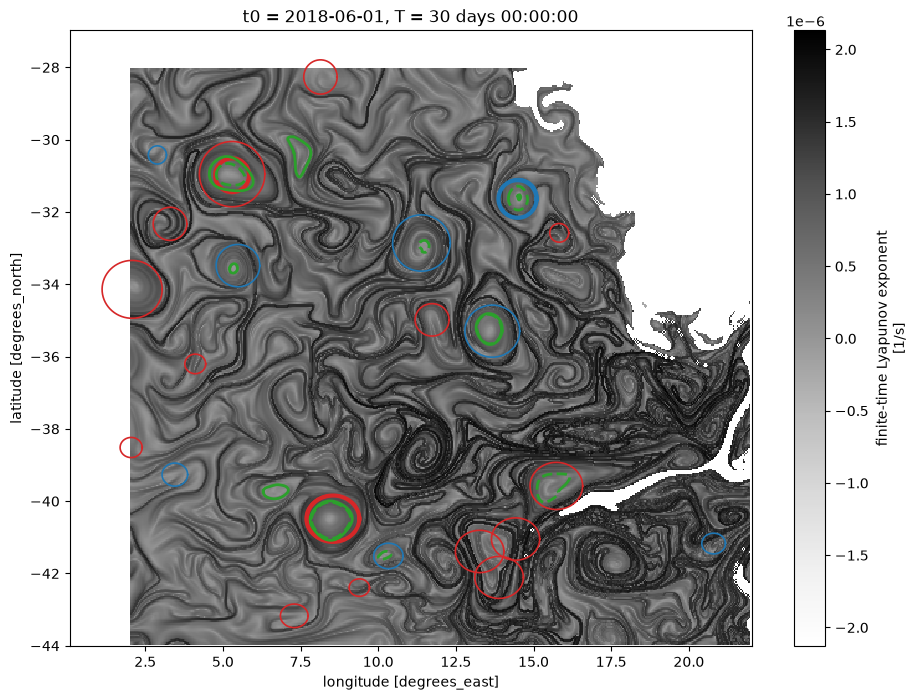

In [48]:
# 1/8 degree
plot_against_gled(
    ftle_eighth, outermost_a=outermost_a_eighth, outermost_b=outermost_b_eighth
)

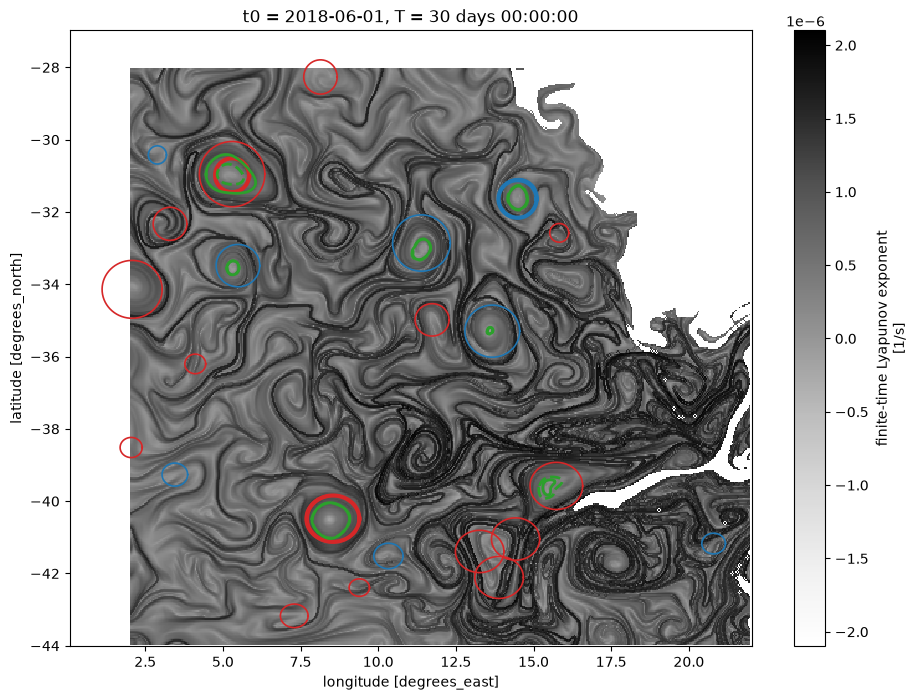

In [49]:
# 1/4 degree
plot_against_gled(
    ftle_quarter, outermost_a=outermost_a_quarter, outermost_b=outermost_b_quarter
)